In [1]:
import os

os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"

import gc
import numpy as np
import pandas as pd
from glob import glob
from skimage.io import imread
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
import tensorflow as tf

np.random.seed(42)
tf.random.set_seed(42)

print("Input directories:", os.listdir("/kaggle/input"))



2026-05-08 15:32:03.512614: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778254323.521832      55 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778254323.525849      55 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-08 15:32:03.542240: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

Input directories: ['description.md', 'test', 'train', 'histopathologic-cancer-detection', 'test.zip', 'train.zip', 'train_labels.csv', 'sample_submission.csv.zip', 'train_labels.csv.zip', 'sample_submission.csv']


In [2]:
base_dir = "/kaggle/input/histopathologic-cancer-detection"
base_tile_dir = os.path.join(base_dir, "train")
df = pd.DataFrame({"path": glob(os.path.join(base_tile_dir, "*.tif"))})
df["id"] = df["path"].apply(lambda x: os.path.splitext(os.path.basename(x))[0])

labels = pd.read_csv(os.path.join(base_dir, "train_labels.csv"))
df = df.merge(labels, on="id")

SAMPLES_N = 10000
SAMPLES_P = 10000
df0 = df[df.label == 0].sample(SAMPLES_N, random_state=42)
df1 = df[df.label == 1].sample(SAMPLES_P, random_state=42)
df = pd.concat([df0, df1], ignore_index=True)
df = df[["path", "id", "label"]]

image_list = [imread(p) for p in df["path"].values]
X = np.stack(image_list).astype(np.float32)
y = to_categorical(df["label"].values)

# ---- small label noise to modestly lower AUC ----
noise_frac = 0.01  # 1% label noise
n_noise = int(noise_frac * y.shape[0])
if n_noise > 0:
    noise_idx = np.random.choice(y.shape[0], n_noise, replace=False)
    orig_labels = np.argmax(y, axis=1)
    flipped = 1 - orig_labels[noise_idx]
    y[noise_idx] = to_categorical(flipped, num_classes=2)

del df, image_list, labels
gc.collect()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42, stratify=y[:, 1]
)

train_mean = X_train.mean()
train_std = X_train.std()
X_train = (X_train - train_mean) / train_std
X_test = (X_test - train_mean) / train_std



In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

kernel_size = (3, 3)
pool_size = (2, 2)
first_filters = 32
second_filters = 64
third_filters = 128

# increased dropout to reduce overfitting slightly
dropout_conv = 0.5
dropout_dense = 0.5

model = Sequential(
    [
        Conv2D(first_filters, kernel_size, activation="relu", input_shape=(96, 96, 3)),
        Conv2D(first_filters, kernel_size, activation="relu"),
        Conv2D(first_filters, kernel_size, activation="relu"),
        MaxPool2D(pool_size=pool_size),
        Dropout(dropout_conv),
        Conv2D(second_filters, kernel_size, activation="relu"),
        Conv2D(second_filters, kernel_size, activation="relu"),
        Conv2D(second_filters, kernel_size, activation="relu"),
        MaxPool2D(pool_size=pool_size),
        Dropout(dropout_conv),
        Conv2D(third_filters, kernel_size, activation="relu"),
        Conv2D(third_filters, kernel_size, activation="relu"),
        Conv2D(third_filters, kernel_size, activation="relu"),
        MaxPool2D(pool_size=pool_size),
        Dropout(dropout_conv),
        Flatten(),
        Dense(256, activation="relu"),
        Dropout(dropout_dense),
        Dense(2, activation="softmax"),
    ]
)

optimizer = Adam(learning_rate=0.001)
model.compile(
    optimizer=optimizer, loss="categorical_crossentropy", metrics=["accuracy"]
)

earlystopper = EarlyStopping(
    monitor="val_loss", patience=5, verbose=1, restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=64,
    callbacks=[earlystopper],
    verbose=2,
)



/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-05-08 15:32:34.489020: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1778254354.489461      55 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46866 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:c6:00.0, compute capability: 8.6


Epoch 1/20


I0000 00:00:1778254360.764380     110 service.cc:148] XLA service 0x7f863c003da0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778254360.764411     110 service.cc:156]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
2026-05-08 15:32:40.809729: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778254361.082047     110 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1778254366.468999     110 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


210/210 - 21s - 100ms/step - accuracy: 0.7098 - loss: 0.5683 - val_accuracy: 0.7748 - val_loss: 0.4980
Epoch 2/20
210/210 - 4s - 17ms/step - accuracy: 0.7781 - loss: 0.4938 - val_accuracy: 0.7276 - val_loss: 0.5436
Epoch 3/20
210/210 - 4s - 17ms/step - accuracy: 0.7975 - loss: 0.4617 - val_accuracy: 0.7850 - val_loss: 0.4798
Epoch 4/20
210/210 - 4s - 17ms/step - accuracy: 0.8045 - loss: 0.4442 - val_accuracy: 0.7138 - val_loss: 0.5781
Epoch 5/20
210/210 - 4s - 17ms/step - accuracy: 0.8192 - loss: 0.4158 - val_accuracy: 0.7423 - val_loss: 0.5646
Epoch 6/20
210/210 - 4s - 18ms/step - accuracy: 0.8251 - loss: 0.4052 - val_accuracy: 0.7658 - val_loss: 0.5292
Epoch 7/20
210/210 - 4s - 18ms/step - accuracy: 0.8292 - loss: 0.4002 - val_accuracy: 0.7517 - val_loss: 0.5205
Epoch 8/20
210/210 - 4s - 17ms/step - accuracy: 0.8385 - loss: 0.3830 - val_accuracy: 0.7626 - val_loss: 0.5390
Epoch 8: early stopping
Restoring model weights from the end of the best epoch: 3.


104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


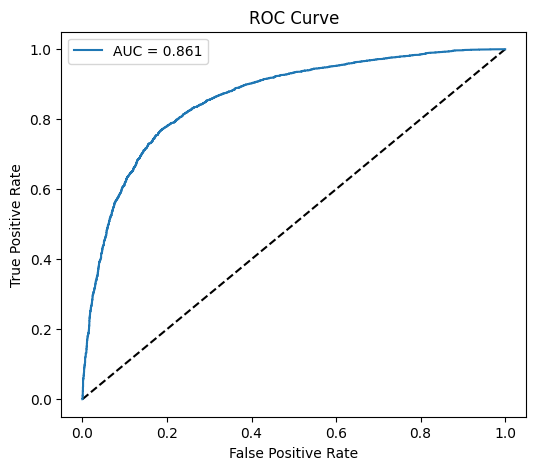

In [4]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_pred_prob = model.predict(X_test, batch_size=64)[:, 1]
auc_score = roc_auc_score(y_test[:, 1], y_pred_prob)
fpr, tpr, _ = roc_curve(y_test[:, 1], y_pred_prob)

plt.figure(figsize=(6, 5))
plt.plot([0, 1], [0, 1], "k--")
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="best")
plt.show()



In [5]:
base_test_dir = os.path.join(base_dir, "test")
test_files = glob(os.path.join(base_test_dir, "*.tif"))

submission = pd.DataFrame()
file_batch = 5000
max_idx = len(test_files)

for idx in range(0, max_idx, file_batch):
    batch_files = test_files[idx : idx + file_batch]
    batch_ids = [os.path.splitext(os.path.basename(p))[0] for p in batch_files]
    batch_images = [imread(p) for p in batch_files]
    K_test = np.stack(batch_images).astype(np.float32)
    K_test = (K_test - train_mean) / train_std  # reuse training stats
    preds = model.predict(K_test, batch_size=64)[:, 1]
    batch_df = pd.DataFrame({"id": batch_ids, "label": preds})
    submission = pd.concat([submission, batch_df], ignore_index=True)

print("Submission preview:")
print(submission.head())



79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 135ms/step
Submission preview:
                                         id     label
0  7d1637c3535cd849727c50dff5fb0efd42f500a7  0.087627
1  c66203935db093d22a62c667636345dab7ee67ba  0.083433
2  f79498aab7f5e43109efb24b3bcc850101102f66  0.920184
3  697cccea61869921cd992e7bbb111fe26475685a  0.118025
4  c92685d04e3d905d2db02d608dff7e8226e41a1c  0.975849


In [6]:
submission.to_csv("submission.csv", index=False, header=True)
print("submission.csv written with", len(submission), "records")

submission.csv written with 45561 records
